<a href="https://colab.research.google.com/github/dhritimanchakra/HCL-Hackathon/blob/main/HCL_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import kagglehub
path = kagglehub.dataset_download("prevek18/ames-housing-dataset")

Using Colab cache for faster access to the 'ames-housing-dataset' dataset.


In [15]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

path = kagglehub.dataset_download("prevek18/ames-housing-dataset")
data = pd.read_csv(path + "/AmesHousing.csv")
data_w = data.select_dtypes(include=[np.number])

Using Colab cache for faster access to the 'ames-housing-dataset' dataset.


<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2663/4039283027.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f})'.format(mu, sigma)], loc='best')
/tmp/ipykernel_2663/4039283027.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_w['SalePrice'], kde=True, hist=True, fit=norm)


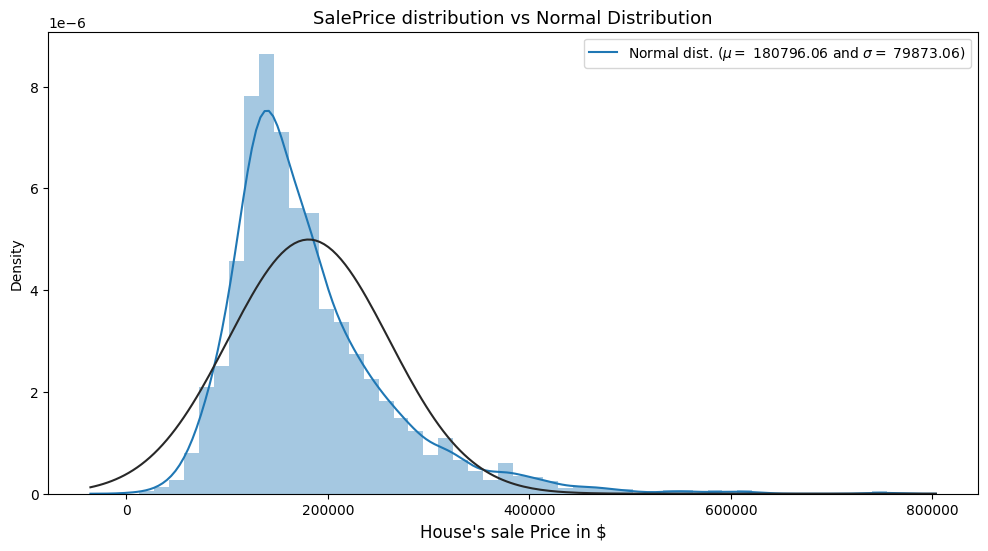

In [16]:
(mu, sigma) = norm.fit(data_w['SalePrice'])

plt.figure(figsize=(12,6))
sns.distplot(data_w['SalePrice'], kde=True, hist=True, fit=norm)
plt.title('SalePrice distribution vs Normal Distribution', fontsize=13)
plt.xlabel("House's sale Price in $", fontsize=12)
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f})'.format(mu, sigma)], loc='best')
plt.show()

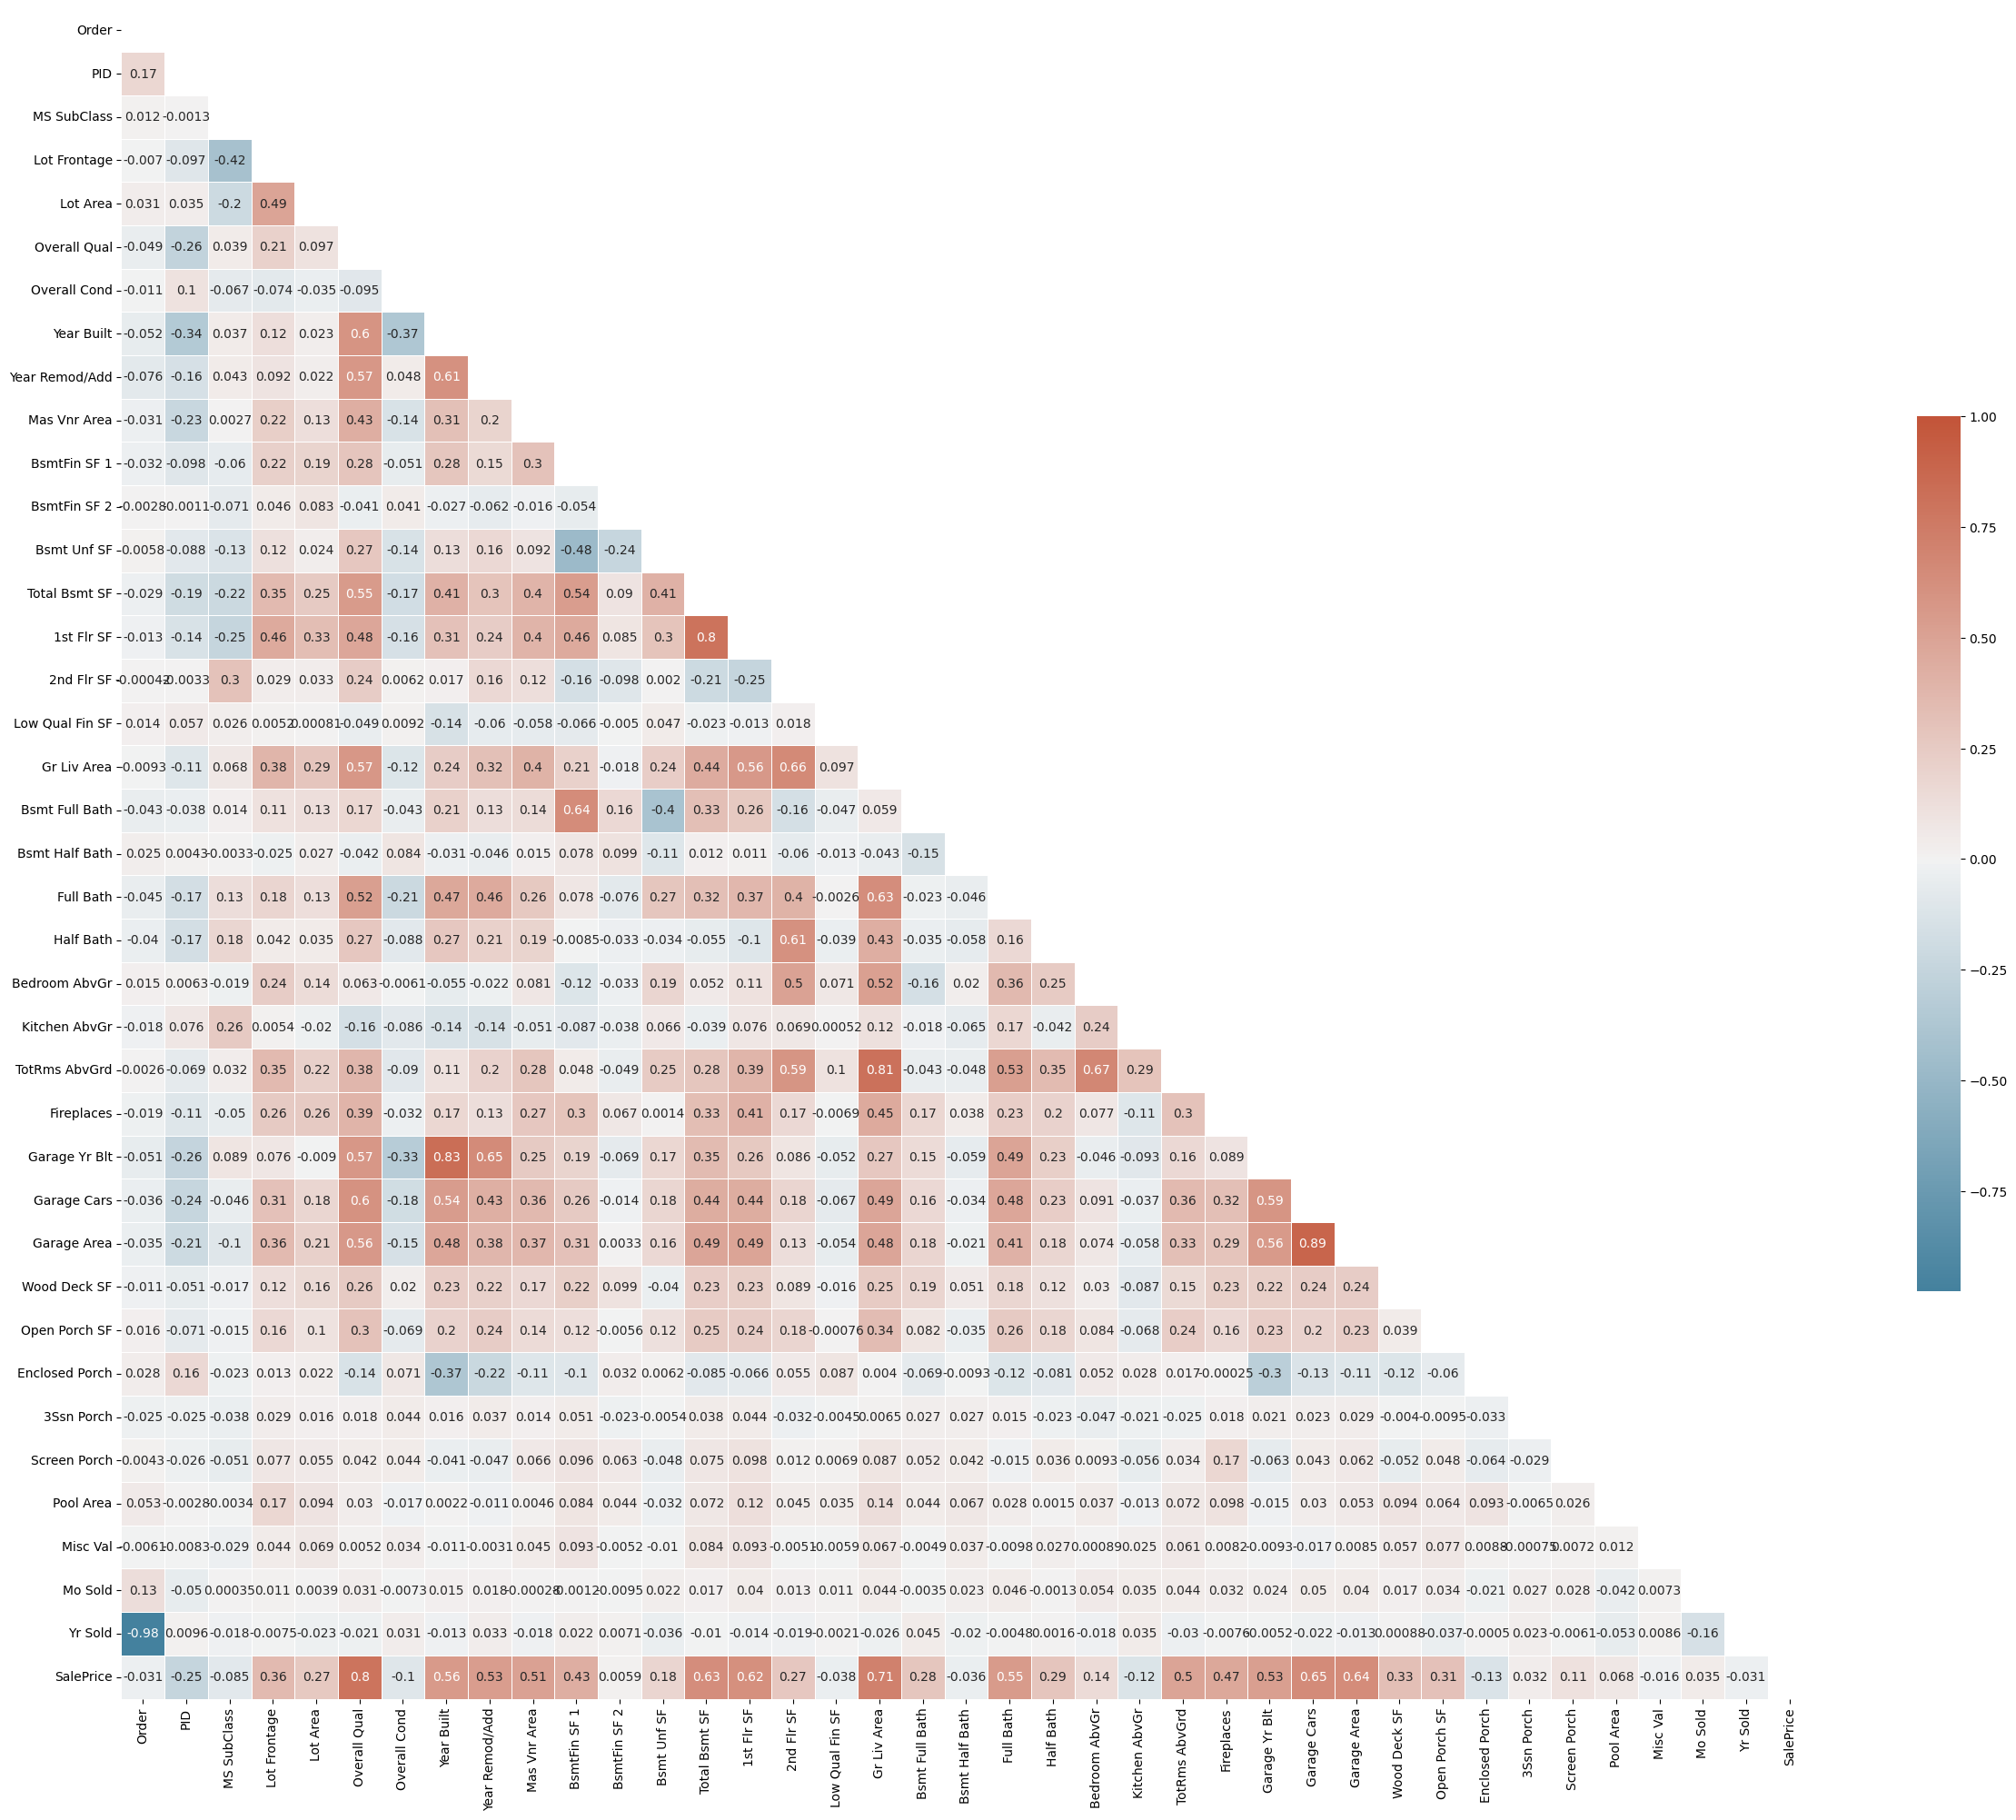

In [17]:
f, ax = plt.subplots(figsize=(30, 25))
mat = data_w.corr('pearson')
mask = np.triu(np.ones_like(mat, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(mat, mask=mask, cmap=cmap, vmax=1, center=0, annot=True,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.show()

/tmp/ipykernel_2663/2979531180.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=data, x='Overall Qual', y='SalePrice', ax=ax[0], palette="Set1")
/tmp/ipykernel_2663/2979531180.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Overall Qual', y='SalePrice', ax=ax[1], palette="Set2")
/tmp/ipykernel_2663/2979531180.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Overall Qual', y='SalePrice', ax=ax[2], palette="Set3")


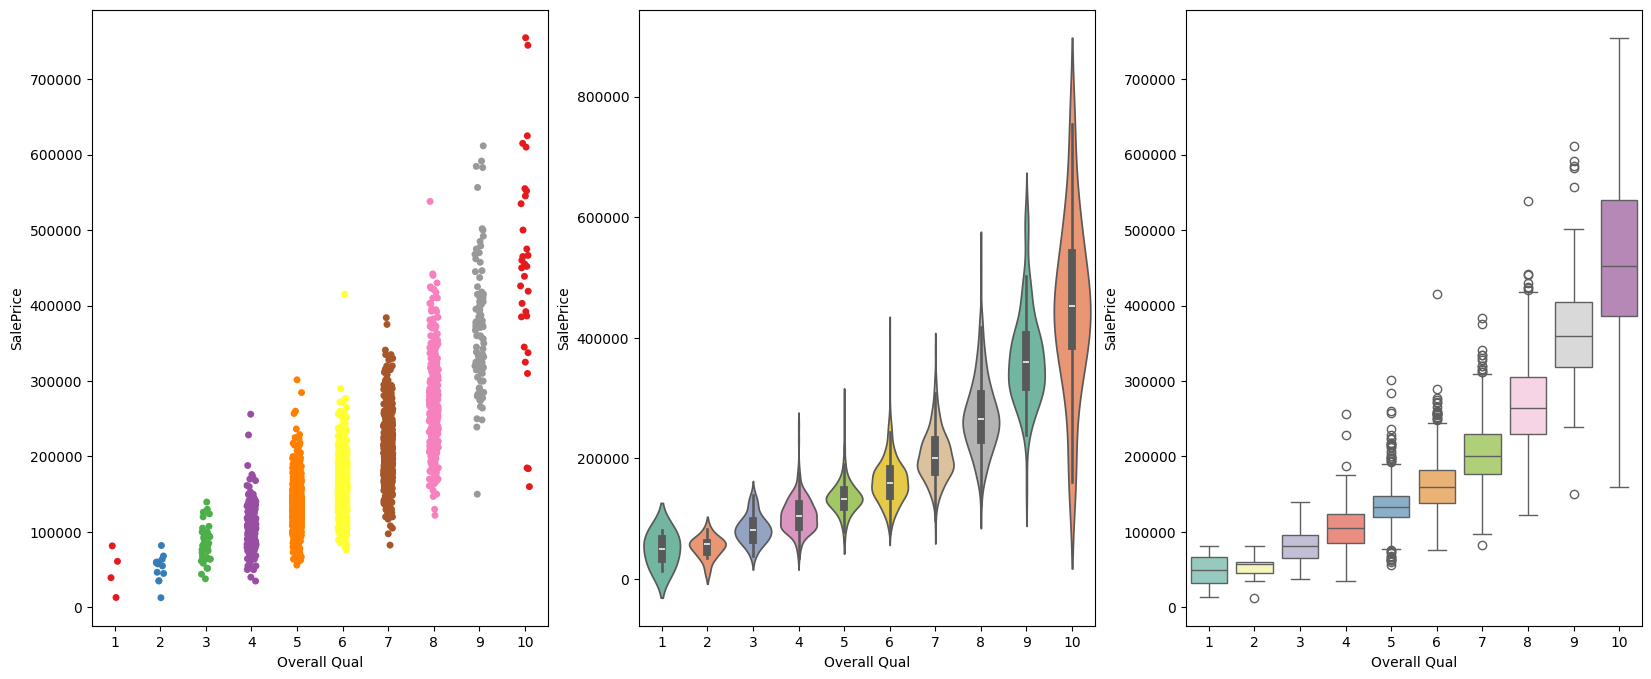

In [18]:
figure, ax = plt.subplots(1,3, figsize=(20,8))

sns.stripplot(data=data, x='Overall Qual', y='SalePrice', ax=ax[0], palette="Set1")
sns.violinplot(data=data, x='Overall Qual', y='SalePrice', ax=ax[1], palette="Set2")
sns.boxplot(data=data, x='Overall Qual', y='SalePrice', ax=ax[2], palette="Set3")

plt.show()

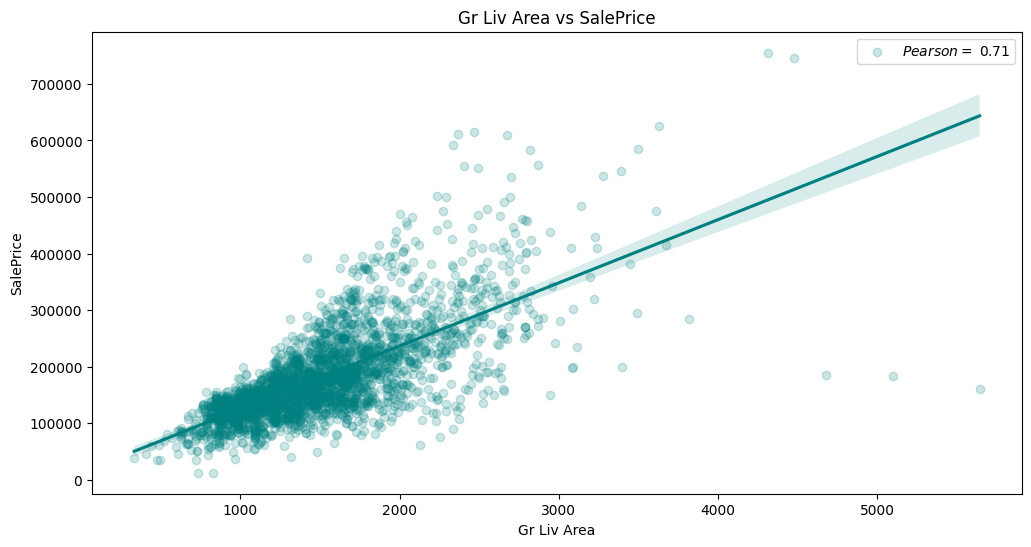

In [19]:
Pearson_GrLiv = 0.71

plt.figure(figsize=(12,6))
sns.regplot(data=data, x='Gr Liv Area', y='SalePrice', scatter_kws={'alpha':0.2}, color='teal')

plt.title('Gr Liv Area vs SalePrice', fontsize=12)
plt.legend(['$Pearson=$ {:.2f}'.format(Pearson_GrLiv)], loc='best')

plt.show()

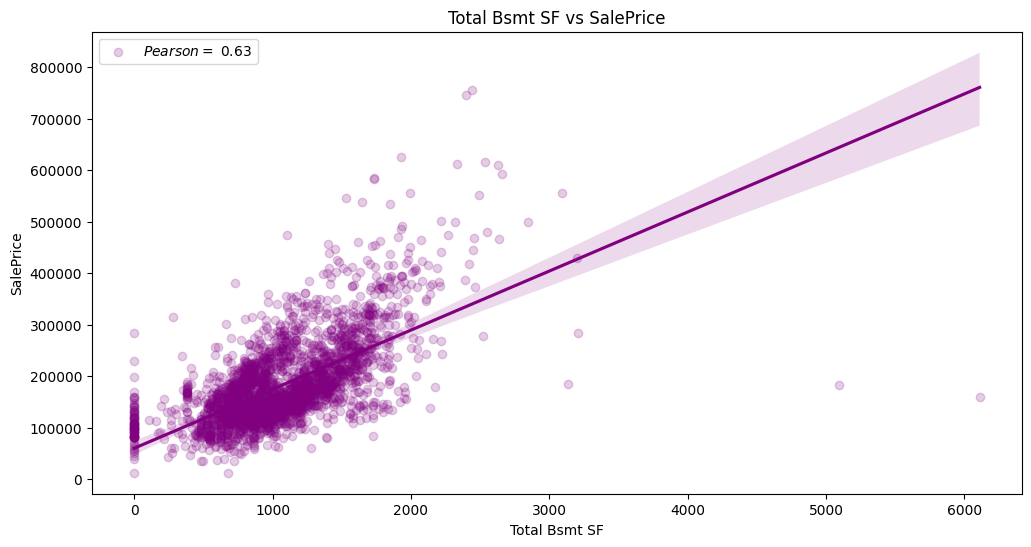

In [20]:
Pearson_TBSF = 0.63

plt.figure(figsize=(12,6))
sns.regplot(data=data, x='Total Bsmt SF', y='SalePrice', scatter_kws={'alpha':0.2}, color='purple')

plt.title('Total Bsmt SF vs SalePrice', fontsize=12)
plt.legend(['$Pearson=$ {:.2f}'.format(Pearson_TBSF)], loc='best')

plt.show()

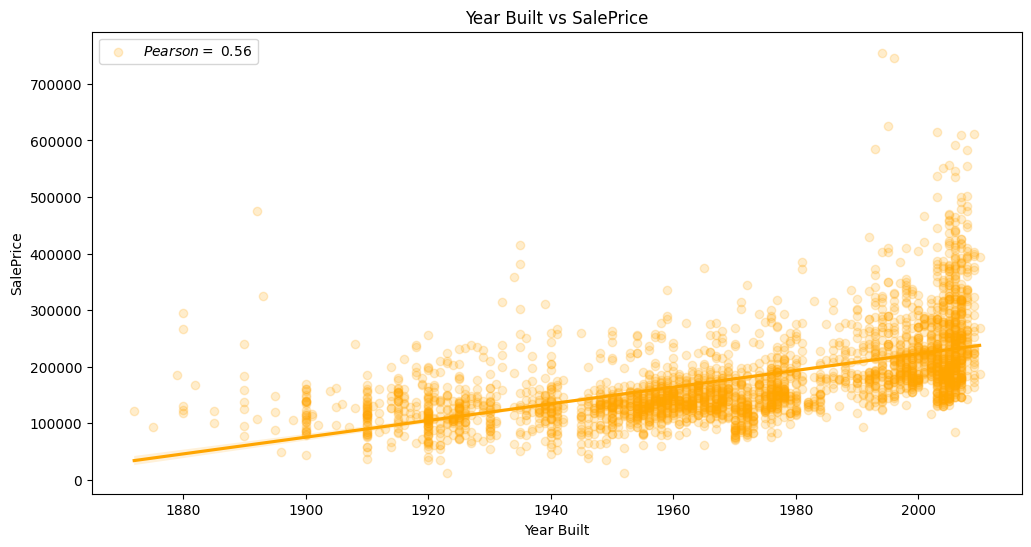

In [21]:
Pearson_YrBlt = 0.56

plt.figure(figsize=(12,6))
sns.regplot(data=data, x='Year Built', y='SalePrice', scatter_kws={'alpha':0.2}, color='orange')

plt.title('Year Built vs SalePrice', fontsize=12)
plt.legend(['$Pearson=$ {:.2f}'.format(Pearson_YrBlt)], loc='best')

plt.show()

/tmp/ipykernel_2663/2546237027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Yr Sold', y='SalePrice', data=data, estimator=np.median, palette='viridis')


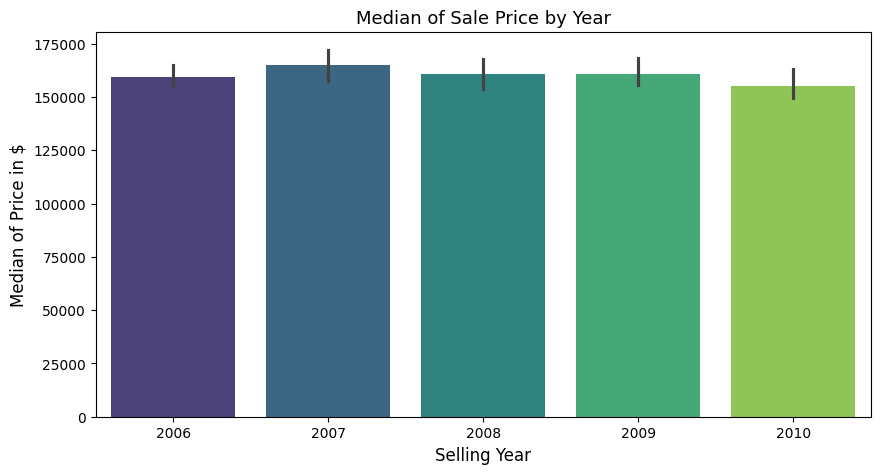

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(x='Yr Sold', y='SalePrice', data=data, estimator=np.median, palette='viridis')

plt.title('Median of Sale Price by Year', fontsize=13)
plt.xlabel('Selling Year', fontsize=12)
plt.ylabel('Median of Price in $', fontsize=12)

plt.show()

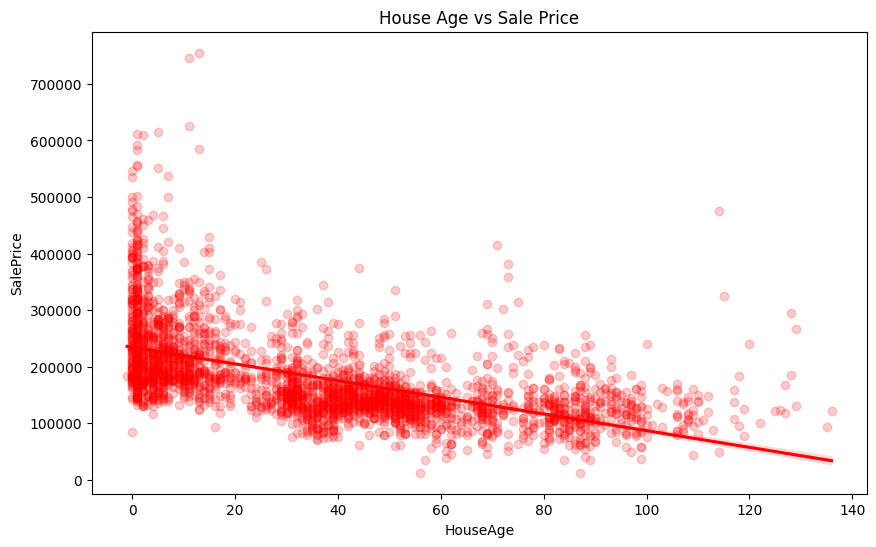

In [23]:
data['HouseAge'] = data['Yr Sold'] - data['Year Built']

plt.figure(figsize=(10,6))
sns.regplot(data=data, x='HouseAge', y='SalePrice', scatter_kws={'alpha':0.2}, color='red')
plt.title('House Age vs Sale Price')
plt.show()

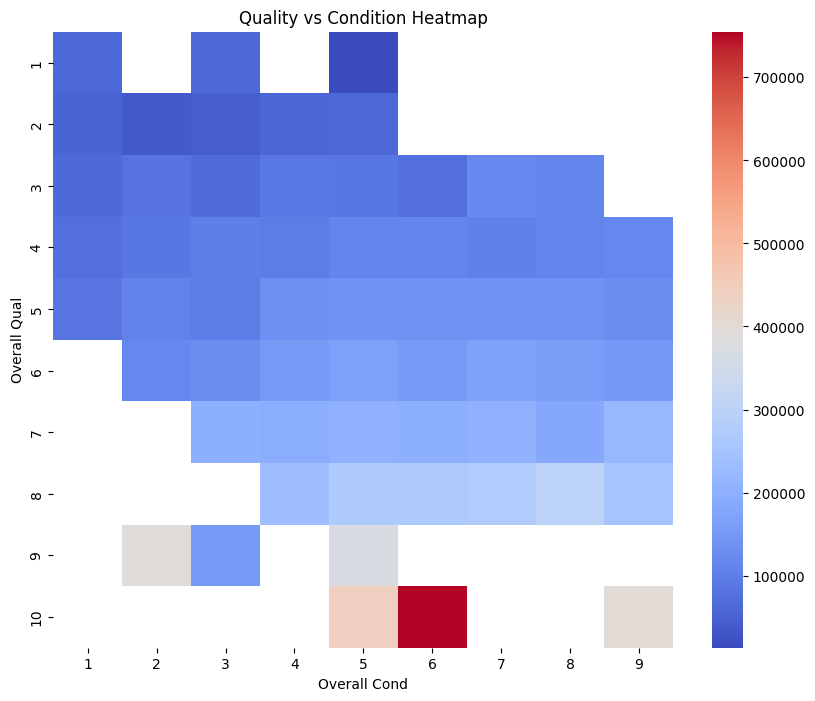

In [24]:
pivot = data.pivot_table(values='SalePrice', index='Overall Qual', columns='Overall Cond')

plt.figure(figsize=(10,8))
sns.heatmap(pivot, cmap='coolwarm')
plt.title('Quality vs Condition Heatmap')
plt.show()

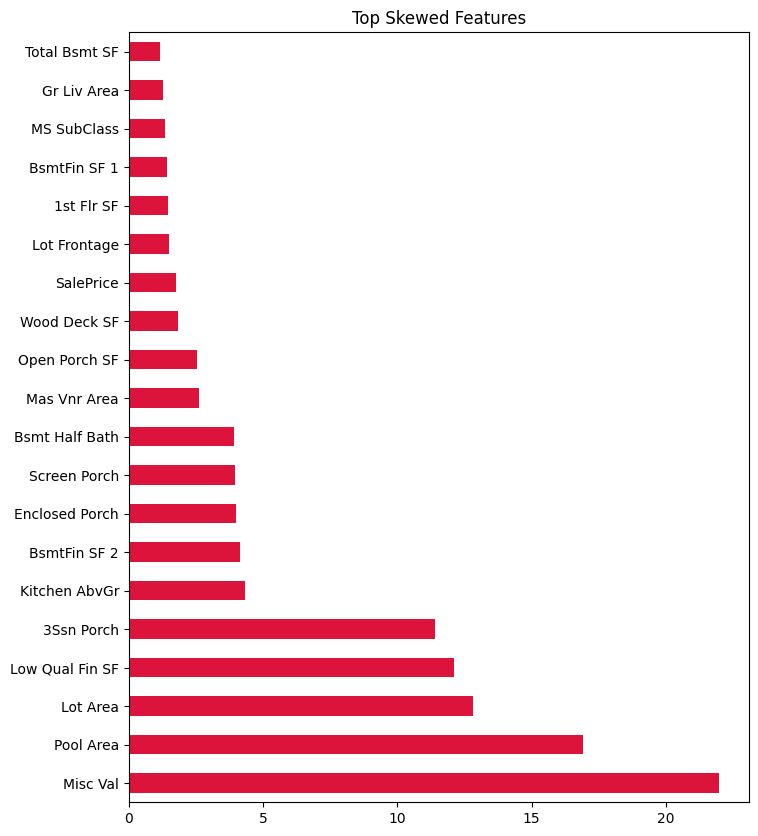

In [25]:
from scipy.stats import skew

numeric = data.select_dtypes(include=np.number)
skewness = numeric.apply(lambda x: skew(x.dropna())).sort_values(ascending=False)

plt.figure(figsize=(8,10))
skewness.head(20).plot(kind='barh', color='crimson')
plt.title('Top Skewed Features')
plt.show()

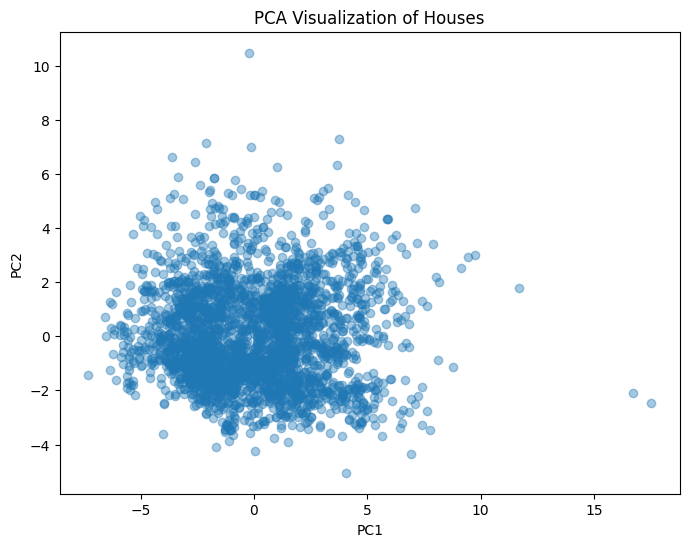

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = data.select_dtypes(include=np.number).drop(columns=['SalePrice']).fillna(0)

scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
comp = pca.fit_transform(scaled)

plt.figure(figsize=(8,6))
plt.scatter(comp[:,0], comp[:,1], alpha=0.4)
plt.title('PCA Visualization of Houses')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()